# Prerequistes

- In order to download ALL card scans we'll setup mtg-bulk-database with postgres and then update ./.env with credentials:

https://github.com/JakeTurner616/mtg-bulk-database

In [1]:
# Cell 1: Install required libraries (if not already installed)
%pip install numpy opencv-python h5py faiss-cpu matplotlib
%pip install psycopg2-binary python-dotenv aiohttp tqdm nest_asyncio

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\jaked\Documents\simple-mtg-feature-detect\venv\Scripts\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\jaked\Documents\simple-mtg-feature-detect\venv\Scripts\python.exe -m pip install --upgrade pip' command.


## Descriptor Extraction Pipeline

This workflow extracts SIFT descriptors from MTG card images and stores them very efficiently:

- Uses only `.h5`, `.index`, and `id_map.json` — no SQLite or extra mappings.
- Appends to `candidate_features.h5` without overwriting existing data.
- Automatically batches descriptors to temp `.npy` files for low memory usage.
- Builds a FAISS index only when new data is added or index is missing.
- Fully resumable and idempotent — reruns won't duplicate or erase data.

# Feature extraction
- Preprocess  with CLAHE adjustments to the luminance channel, and convert back to the RGB color space
- Extract features using SIFT, apply RootSIFT normalization, and Product Quantization into an Inverted File Index
- ~~Generate a index_to_card.txt for robust searching of keypoints with RANSAC~~
- Add to existing model files instead of creating new ones each time

In [ ]:
import os
import json
import gc
import numpy as np
import psycopg2
import psycopg2.extras
import h5py
import faiss
import psutil
import tempfile
from dotenv import load_dotenv
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
from workers.feature_worker import process_record

# ---------------------------
# CONFIG
# ---------------------------
load_dotenv('.env')
DB_USER = os.getenv("POSTGRES_USER", "mtguser")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD", "mtgpass")
DB_NAME = os.getenv("POSTGRES_DB", "mtgdb")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")

H5_FEATURES_FILE = 'resources/run/candidate_features.h5'
FAISS_INDEX_FILE = 'resources/run/faiss_ivf.index'
ID_MAP_FILE = 'resources/run/id_map.json'
EVAL_SAMPLE_COUNT = 10
MAX_WORKERS = 4
MEMORY_UPDATE_EVERY = 10
FAISS_BATCH_SIZE = 5000

raw_limit = os.getenv("DATASET_LIMIT")
dataset_limit = int(raw_limit) if raw_limit and raw_limit.isdigit() else None

def get_memory_usage():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# ---------------------------
# LOAD RECORDS
# ---------------------------
def load_card_records():
    limit_clause = f"LIMIT {dataset_limit}" if dataset_limit else ""
    conn = psycopg2.connect(
        dbname=DB_NAME, user=DB_USER, password=DB_PASSWORD,
        host=DB_HOST, port=DB_PORT
    )
    query = f"""
        SELECT id AS scryfall_id,
               COALESCE(image_uris->>'png', image_uris->>'large') AS image_url,
               0 AS face_index
        FROM cards
        WHERE layout::text NOT IN ('art_series', 'scheme', 'plane', 'phenomenon')
        AND games @> '["paper"]'
        AND lang = 'en'
        AND digital = false
        AND (promo IS NULL OR promo = false)
        AND image_uris IS NOT NULL
        {limit_clause}
    """
    with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
        cur.execute(query)
        return cur.fetchall()

card_records = load_card_records()

# ---------------------------
# HDF5 SETUP
# ---------------------------
if os.path.exists(H5_FEATURES_FILE):
    with h5py.File(H5_FEATURES_FILE, 'a') as hf:
        processed_ids = set(hf.keys())
else:
    with h5py.File(H5_FEATURES_FILE, 'w'):
        pass
    processed_ids = set()

new_records = [r for r in card_records if r['scryfall_id'] not in processed_ids]
tqdm.write(f"Total records: {len(card_records)} | New to process: {len(new_records)}")

# ---------------------------
# EXTRACTION + INDEXING
# ---------------------------
eval_samples = []
descriptor_files = []
batch_descriptors = []
id_map = []
descriptor_count = 0

with tempfile.TemporaryDirectory() as temp_dir:
    with h5py.File(H5_FEATURES_FILE, 'a') as hf, ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        progress = tqdm(total=len(new_records), desc="Extracting features", unit="img")
        for i, result in enumerate(executor.map(process_record, new_records)):
            if not result:
                progress.update(1)
                continue

            scryfall_id = result["scryfall_id"]
            image_url = result["image_url"]
            keypoints = result["keypoints"]
            descriptors = np.array(result["descriptors"], dtype=np.float16)

            card_grp = hf.create_group(scryfall_id) if scryfall_id not in hf else hf[scryfall_id]
            feat_grp = card_grp.create_group(f"feature_{len(card_grp)}")
            feat_grp.create_dataset("descriptors", data=descriptors, compression="gzip", compression_opts=3, chunks=True)
            feat_grp.create_dataset("keypoints", data=[json.dumps(keypoints)],
                                    dtype=h5py.string_dtype(encoding="utf-8"),
                                    compression="gzip", compression_opts=3, chunks=True)
            feat_grp.attrs["image_url"] = image_url

            batch_descriptors.extend([d.astype(np.float32) for d in descriptors])
            id_map.extend([scryfall_id] * len(descriptors))
            descriptor_count += len(descriptors)

            if len(eval_samples) < EVAL_SAMPLE_COUNT:
                eval_samples.append({
                    "scryfall_id": scryfall_id,
                    "image_url": image_url,
                    "face_index": result["face_index"]
                })

            if descriptor_count >= FAISS_BATCH_SIZE:
                path = os.path.join(temp_dir, f"descriptors_{len(descriptor_files)}.npy")
                np.save(path, np.vstack(batch_descriptors))
                descriptor_files.append(path)
                batch_descriptors.clear()
                descriptor_count = 0
                gc.collect()

            if i % MEMORY_UPDATE_EVERY == 0:
                progress.set_postfix(mem=f"{get_memory_usage():.1f} MB")
            progress.update(1)
        progress.close()

    # Final flush
    if batch_descriptors:
        path = os.path.join(temp_dir, f"descriptors_{len(descriptor_files)}.npy")
        np.save(path, np.vstack(batch_descriptors))
        descriptor_files.append(path)
        batch_descriptors.clear()
        gc.collect()

    # ---------------------------
    # INCREMENTAL-SAFE INDEX + ID MAP
    # ---------------------------
    existing_id_map = []
    existing_index = None
    index_dim = None

    if os.path.exists(ID_MAP_FILE):
        with open(ID_MAP_FILE, 'r') as f:
            existing_id_map = json.load(f)

    if os.path.exists(FAISS_INDEX_FILE):
        existing_index = faiss.read_index(FAISS_INDEX_FILE)
        index_dim = existing_index.d
        tqdm.write("[INFO] Loaded existing FAISS index.")

    if descriptor_files:
        tqdm.write(f"[INFO] Building FAISS index from {len(descriptor_files)} descriptor files.")
        mmap_refs = []
        for path in descriptor_files:
            arr = np.load(path, mmap_mode='r')
            mmap_refs.append(np.array(arr))
            del arr
        new_descriptors = np.vstack(mmap_refs)
        dim = new_descriptors.shape[1]

        if existing_index:
            if index_dim != dim:
                raise ValueError(f"[ERROR] Descriptor dimensionality mismatch: {index_dim} (existing) vs {dim} (new)")
            index = existing_index
            tqdm.write("[INFO] Appending to existing FAISS index.")
        else:
            if len(existing_id_map) + len(id_map) < 10000:
                index = faiss.IndexFlatL2(dim)
                tqdm.write("[INFO] Created new IndexFlatL2.")
            else:
                quantizer = faiss.IndexFlatL2(dim)
                index = faiss.IndexIVFPQ(quantizer, dim, 100, 8, 8)
                index.train(new_descriptors[:10000])
                index.nprobe = 10
                tqdm.write("[INFO] Trained new IVF-PQ index.")

        index.add(new_descriptors)
        faiss.write_index(index, FAISS_INDEX_FILE)
        tqdm.write(f"✅ FAISS index written to disk with {index.ntotal} total descriptors.")

        full_id_map = existing_id_map + id_map
        with open(ID_MAP_FILE, "w") as f:
            json.dump(full_id_map, f)
        tqdm.write(f"✅ Saved updated ID map with {len(full_id_map)} entries.")


Total records: 86149 | New to process: 86149


Extracting features: 100%|██████████| 86149/86149 [1:42:00<00:00, 14.07img/s, mem=413.9 MB]  


[INFO] Building FAISS index from 1701 descriptor files.
[INFO] Trained new IVF-PQ index.
✅ FAISS index written to disk with 8501657 total descriptors.
✅ Saved updated ID map with 8501657 entries.


# Inference and Test accuracy

Query image: https://cards.scryfall.io/large/front/3/3/3394cefd-a3c6-4917-8f46-234e441ecfb6.jpg?1592487887
Expected IDs: ['3394cefd-a3c6-4917-8f46-234e441ecfb6', '710160a6-43b4-4ba7-9dcd-93e01befc66f']
Predicted ID: 3394cefd-a3c6-4917-8f46-234e441ecfb6
✅ Prediction is CORRECT (matched one of the valid IDs).


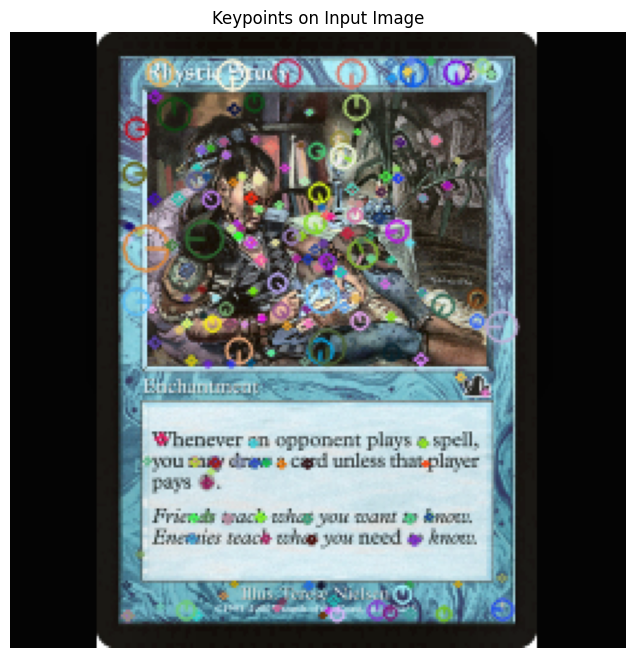


Debug Info:
{'keypoints': 250,
 'inliers': {'710160a6-43b4-4ba7-9dcd-93e01befc66f': 46,
             '3394cefd-a3c6-4917-8f46-234e441ecfb6': 48,
             '03ac9b21-8c79-49ec-a0df-0fd22e4a0ed7': 27,
             'd6914dba-0d27-4055-ac34-b3ebf5802221': 21,
             'aeb282bb-d0b8-4822-8197-ff0523549309': 14,
             '1cb8ae53-a53f-4a0f-94f7-559aca041797': 15,
             '4363ec0d-a473-4afc-9ae5-4feed762a630': 0,
             'b4574869-9598-4295-bd43-ce3633e0d8e6': 0,
             '9532d03d-a4c2-44c4-ae14-3f8e0bce79a5': 5,
             'bc97ffcf-4f51-44cd-8daa-a7dae4592ee5': 0}}


In [3]:
import os
import cv2
import json
import faiss
import h5py
import numpy as np
import requests
import matplotlib.pyplot as plt
from collections import Counter
import time
from pprint import pprint

# ---------------------------
# CONFIG
# ---------------------------
H5_FEATURES_FILE = "resources/run/candidate_features.h5"
FAISS_INDEX_FILE = "resources/run/faiss_ivf.index"
ID_MAP_FILE = "resources/run/id_map.json"

# ---------------------------
# LOAD RESOURCES
# ---------------------------
index = faiss.read_index(FAISS_INDEX_FILE)
hf = h5py.File(H5_FEATURES_FILE, 'r')

with open(ID_MAP_FILE, 'r') as f:
    id_map = json.load(f)

# ---------------------------
# SIFT + CLAHE + DESERIALIZATION HELPERS
# ---------------------------
sift = cv2.SIFT_create(nfeatures=250)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def extract_features(image):
    # Preserve aspect ratio: resize so largest side = 256
    h, w = image.shape[:2]
    scale = 256.0 / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pad to square (256x256) if needed
    delta_w = 256 - new_w
    delta_h = 256 - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])

    lab = cv2.cvtColor(padded, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    L_clahe = clahe.apply(L)
    lab_clahe = cv2.merge((L_clahe, A, B))
    enhanced_color = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    gray = cv2.cvtColor(enhanced_color, cv2.COLOR_BGR2GRAY)

    keypoints, descriptors = sift.detectAndCompute(gray, None)
    if descriptors is not None:
        eps = 1e-7
        descriptors = descriptors / (descriptors.sum(axis=1, keepdims=True) + eps)
        descriptors = np.sqrt(descriptors).astype(np.float32)

    return keypoints, descriptors, enhanced_color

def deserialize_keypoints(serialized):
    return [
        cv2.KeyPoint(d['pt'][0], d['pt'][1], d['size'], d['angle'], d['response'], d['octave'], d['class_id'])
        for d in serialized
    ]

def load_features_for_card(card_id):
    feats = []
    if card_id in hf:
        for fkey in hf[card_id].keys():
            dset = hf[card_id][fkey]
            kp_json = dset["keypoints"][()][0]
            kp_str = kp_json.decode("utf-8") if isinstance(kp_json, bytes) else kp_json
            descriptors = dset["descriptors"][()].astype(np.float32)
            feats.append((deserialize_keypoints(json.loads(kp_str)), descriptors))
    return feats

# ---------------------------
# RANSAC-MATCHED INFERENCE
# ---------------------------
def find_closest_card_ransac(image, index, hf, id_map, k=3, inlier_thresh=8, max_candidates=10):
    debug = {}
    keypoints, descriptors, processed = extract_features(image)
    debug['keypoints'] = len(keypoints) if keypoints else 0
    if descriptors is None or len(keypoints) == 0:
        return None, keypoints, processed, {'error': 'No descriptors'}

    D, I = index.search(descriptors, k)
    flat = I.flatten()
    candidate_ids = [id_map[i] for i in flat if i < len(id_map)]
    counts = Counter(candidate_ids)
    sorted_cands = [cid for cid, _ in counts.most_common(max_candidates)]

    bf = cv2.BFMatcher()
    best = None
    max_inliers = 0
    timings = {}

    for cid in sorted_cands:
        start = time.perf_counter()
        sets = load_features_for_card(cid)
        total_inliers = 0

        for cand_kp, cand_des in sets:
            matches = bf.knnMatch(descriptors, cand_des, k=2)
            good = [m for m, n in matches if m.distance < 0.75 * n.distance]
            if len(good) >= 4:
                src_pts = np.float32([keypoints[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
                dst_pts = np.float32([cand_kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
                _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
                if mask is not None:
                    total_inliers += int(mask.sum())

        timings[cid] = total_inliers
        if total_inliers > max_inliers:
            max_inliers = total_inliers
            best = cid

    debug['inliers'] = timings
    if max_inliers < inlier_thresh:
        return None, keypoints, processed, debug
    return best, keypoints, processed, debug

# ---------------------------
# INFERENCE SAMPLE
# ---------------------------
sample = {
    "scryfall_ids": [
        "3394cefd-a3c6-4917-8f46-234e441ecfb6",
        "710160a6-43b4-4ba7-9dcd-93e01befc66f"
    ],
    "image_url": "https://cards.scryfall.io/large/front/3/3/3394cefd-a3c6-4917-8f46-234e441ecfb6.jpg?1592487887"
}
image_url = sample["image_url"]
ground_truth_ids = set(sample["scryfall_ids"])

response = requests.get(image_url)
image_array = np.frombuffer(response.content, np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Run full inference
pred_id, keypoints, processed_img, debug_info = find_closest_card_ransac(
    image, index, hf, id_map, k=3
)

# ---------------------------
# OUTPUT RESULTS
# ---------------------------
print(f"Query image: {image_url}")
print(f"Expected IDs: {list(ground_truth_ids)}")
print(f"Predicted ID: {pred_id}")

if pred_id in ground_truth_ids:
    print("✅ Prediction is CORRECT (matched one of the valid IDs).")
else:
    print("❌ Prediction is INCORRECT (did not match any valid IDs).")

# ---------------------------
# VISUALIZE
# ---------------------------
image_with_kp = cv2.drawKeypoints(processed_img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image_with_kp, cv2.COLOR_BGR2RGB))
plt.title("Keypoints on Input Image")
plt.axis("off")
plt.show()

# ---------------------------
# DEBUG INFO
# ---------------------------
print("\nDebug Info:")
pprint(debug_info, sort_dicts=False)


## Package the resources.zip:

In [4]:
import zipfile
import os

# ---------------------------
# CONFIG
# ---------------------------
OUTPUT_ZIP = 'resourcesV4.zip'
FILES_TO_INCLUDE = [
    'resources/run/candidate_features.h5',
    'resources/run/faiss_ivf.index',
    'resources/run/id_map.json',
]

# ---------------------------
# ZIP PACKAGING
# ---------------------------
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path in FILES_TO_INCLUDE:
        if os.path.exists(file_path):
            arcname = os.path.relpath(file_path, start='resources')
            zipf.write(file_path, arcname=os.path.join('resources', arcname))
            print(f"✔️ Added: {file_path}")
        else:
            print(f"⚠️ Skipped (not found): {file_path}")

print(f"\n📦 Packaged inference archive saved to: {OUTPUT_ZIP}")


✔️ Added: resources/run/candidate_features.h5
✔️ Added: resources/run/faiss_ivf.index
✔️ Added: resources/run/id_map.json

📦 Packaged inference archive saved to: resourcesV4.zip
